In [4]:
import os
from PIL import Image

In [9]:
train_dir = 'signs'

In [22]:
import os
from PIL import Image

image_classes = {}
for i in range(10):  # 0-9
    image_classes[str(i)] = []
for letter in range(ord('a'), ord('z') + 1):  # a-z
    image_classes[chr(letter)] = []

for class_name in image_classes.keys():
    class_path = os.path.join(train_dir, class_name)
    
    if os.path.isdir(class_path):
        for count, image_name in enumerate(os.listdir(class_path), start=1):
            image_path = os.path.join(class_path, image_name)
            try:
                image = Image.open(image_path)
                new_name = f"img{count}{os.path.splitext(image_name)[1]}"
                new_path = os.path.join(class_path, new_name)
                os.rename(image_path, new_path)
                
                image_classes[class_name].append((image, new_name))
                    
            except Exception as e:
                print(f"Error loading image {image_path}: {e}")

def create_thumbnails(images, size=(256, 256)):
    for idx in range(len(images)):
        img, name = images[idx]
        img.thumbnail(size)
        images[idx] = (img, name)

for class_name, images in image_classes.items():
    create_thumbnails(images)

for class_name, images in image_classes.items():
    if images:
        images[0][0].show()
        print(f"Label: {class_name}, New Name: {images[0][1]}")


Label: 0, New Name: img1.jpeg
Label: 1, New Name: img1.jpeg
Label: 2, New Name: img1.jpeg
Label: 3, New Name: img1.jpeg
Label: 4, New Name: img1.jpeg
Label: 5, New Name: img1.jpeg
Label: 6, New Name: img1.jpeg
Label: 7, New Name: img1.jpeg
Label: 8, New Name: img1.jpeg
Label: 9, New Name: img1.jpeg
Label: a, New Name: img1.jpeg
Label: b, New Name: img1.jpeg
Label: c, New Name: img1.jpeg
Label: d, New Name: img1.jpeg
Label: e, New Name: img1.jpeg
Label: f, New Name: img1.jpeg
Label: g, New Name: img1.jpeg
Label: h, New Name: img1.jpeg
Label: i, New Name: img1.jpeg
Label: j, New Name: img1.jpeg
Label: k, New Name: img1.jpeg
Label: l, New Name: img1.jpeg
Label: m, New Name: img1.jpeg
Label: n, New Name: img1.jpeg
Label: o, New Name: img1.jpeg
Label: p, New Name: img1.jpeg
Label: q, New Name: img1.jpeg
Label: r, New Name: img1.jpeg
Label: s, New Name: img1.jpeg
Label: t, New Name: img1.jpeg
Label: u, New Name: img1.jpeg
Label: v, New Name: img1.jpeg
Label: w, New Name: img1.jpeg
Label: x, 

In [23]:
from fastai.vision.all import *

In [25]:
classes_to_view = ['0', '1', '2', '3'] 
num_images_to_show = 1

for class_name in classes_to_view:
    if class_name in image_classes:
        images = image_classes[class_name]
        for i in range(min(num_images_to_show, len(images))):
            images[i][0].show()  
            print(f"Label: {class_name}, New Name: {images[i][1]}")


Label: 0, New Name: img1.jpeg
Label: 1, New Name: img1.jpeg
Label: 2, New Name: img1.jpeg
Label: 3, New Name: img1.jpeg


In [28]:
path = train_dir
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Random_Resized_Crop(256,min_scale= 0.3),
    batch_tfms=aug_transforms(size=224)
).dataloaders(path, bs=32)

In [29]:
print(dls.vocab)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [77]:
learner = vision_learner(dls, resnet18, metrics=accuracy)
learner.fine_tune(1)

epoch,train_loss,valid_loss,accuracy,time
0,3.625409,1.002339,0.684211,00:28


epoch,train_loss,valid_loss,accuracy,time
0,1.278250,0.540440,0.830827,00:38


This is a: 6.
Probability distribution: {'0': tensor(0.0009), '1': tensor(0.0001), '2': tensor(0.0075), '3': tensor(0.0005), '4': tensor(0.0636), '5': tensor(0.0049), '6': tensor(0.5595), '7': tensor(0.2135), '8': tensor(0.0238), '9': tensor(0.0011), 'a': tensor(4.7062e-05), 'b': tensor(0.0024), 'c': tensor(0.0003), 'd': tensor(0.0006), 'e': tensor(0.0003), 'f': tensor(0.0002), 'g': tensor(0.0008), 'h': tensor(0.0003), 'i': tensor(6.2365e-05), 'j': tensor(0.0003), 'k': tensor(0.0004), 'l': tensor(0.0003), 'm': tensor(3.5679e-05), 'n': tensor(4.9201e-05), 'o': tensor(0.0004), 'p': tensor(6.2196e-05), 'q': tensor(7.6130e-05), 'r': tensor(0.0009), 's': tensor(3.1609e-05), 't': tensor(3.6253e-05), 'u': tensor(0.0002), 'v': tensor(0.0729), 'w': tensor(0.0432), 'x': tensor(0.0002), 'y': tensor(8.7373e-05), 'z': tensor(0.0006)}


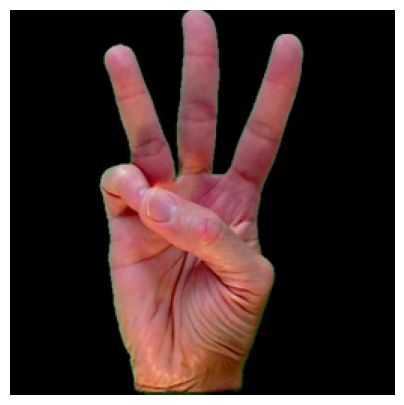

In [80]:
import random

classes = list(image_classes.keys())
random_class = random.choice(classes)
i = random.randint(0, len(image_classes[random_class]) - 1)
img = image_classes[random_class][i][0]

predicted_class, _, probs = learner.predict(img)

img.show()
print(f"This is a: {predicted_class}.")
print(f"Probability distribution: {dict(zip(classes, probs))}")


Actual Class: p
Predicted Class: p
CORRECT 


Actual Class: 3
Predicted Class: 7



Actual Class: u
Predicted Class: u
CORRECT 


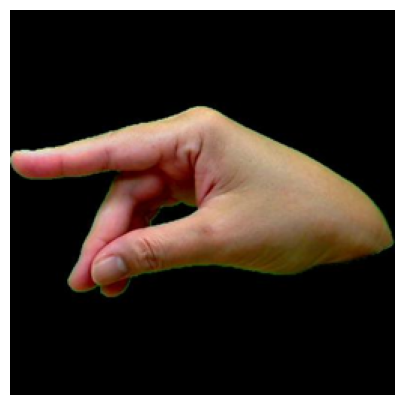

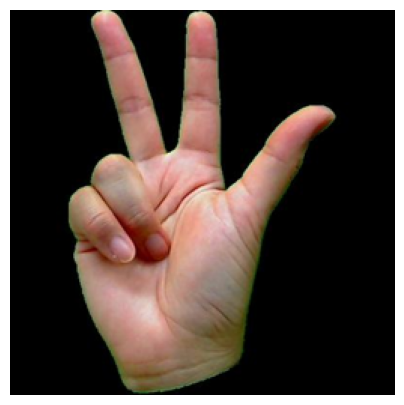

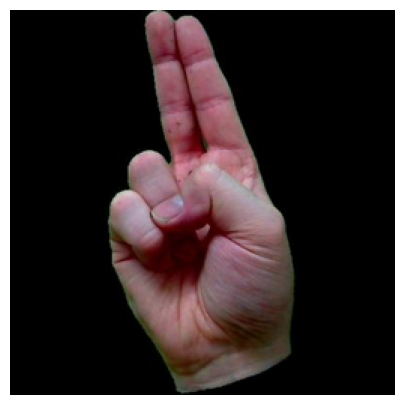

In [83]:
import random

def validate_model(image_classes, learner, num_samples=3):
    classes = list(image_classes.keys())
    
    for _ in range(num_samples):
        random_class = random.choice(classes)
        
        images = image_classes[random_class]
        if images:
            random_index = random.randint(0, len(images) - 1)
            img, _ = images[random_index]
            
            predicted_class, _, probs = learner.predict(img)
            
            img.show()
            print(f"Actual Class: {random_class}")
            print(f"Predicted Class: {predicted_class}")
            if random_class == predicted_class:
                print("CORRECT ")
            else:
                print("")

validate_model(image_classes, learner, num_samples=3)


In [84]:
import cv2
import numpy as np
from fastai.vision.all import *
from PIL import Image
import time

cam = cv2.VideoCapture(0)

predicted_string = ""
last_capture_time = time.time()

while True:
    ret, frame = cam.read()
    if not ret:
        break
    
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb_frame)
    pil_image = pil_image.resize((224, 224))

    current_time = time.time()
    if current_time - last_capture_time >= 3:
        last_capture_time = current_time
        predicted_class, _, probs = learner.predict(pil_image)

        confidence = probs.max().item()   
        if confidence > 0.70:   
            predicted_string += str(predicted_class)
            print(f"Detected: {predicted_class} with confidence: {confidence:.2f}")   
        else:
            print(f"Prediction confidence {confidence:.2f}  with {predicted_class} is below threshold.")   

    cv2.putText(frame, f"Taking: {predicted_string}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
    
    cv2.imshow('Sign Language Recognition', frame)
    
    if cv2.waitKey(1) == ord('q'):
        break

cam.release()
cv2.destroyAllWindows()


Prediction confidence 0.27  with z is below threshold.


Prediction confidence 0.24  with z is below threshold.


Prediction confidence 0.36  with i is below threshold.


Prediction confidence 0.20  with i is below threshold.


Prediction confidence 0.22  with q is below threshold.


...

Prediction confidence 0.42  with i is below threshold.


Prediction confidence 0.17  with z is below threshold.


Prediction confidence 0.26  with z is below threshold.


Prediction confidence 0.31  with z is below threshold.


Prediction confidence 0.58  with z is below threshold.
